In [ ]:
# Connect to your Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Change this path if your camp folder is somewhere else.
%cd /content/drive/MyDrive/AI Summer Intensive 2026/Day 2

/content/drive/MyDrive/Everything USF/DRAFT AI Summer Camp/Group project -- template code


In [ ]:
df = pd.read_csv("data/restaurant_visitors.csv",parse_dates=["date"])
df.head()

,date,day_of_week,month,is_weekend,is_holiday,reservation_status,reserved_visitors,reservation_count,visitors
0,2016-01-02,Saturday,1,1,1,No advance reservations,0,0,6
1,2016-01-03,Sunday,1,1,1,Reservations recorded,4,1,65
2,2016-01-04,Monday,1,0,0,No advance reservations,0,0,91
3,2016-01-07,Thursday,1,0,0,Reservations recorded,5,1,7
4,2016-01-09,Saturday,1,1,0,Reservations recorded,20,5,70


In [ ]:
print(f"Total rows: {len(df)}")

Total rows: 437


# Exploratory Data Analysis

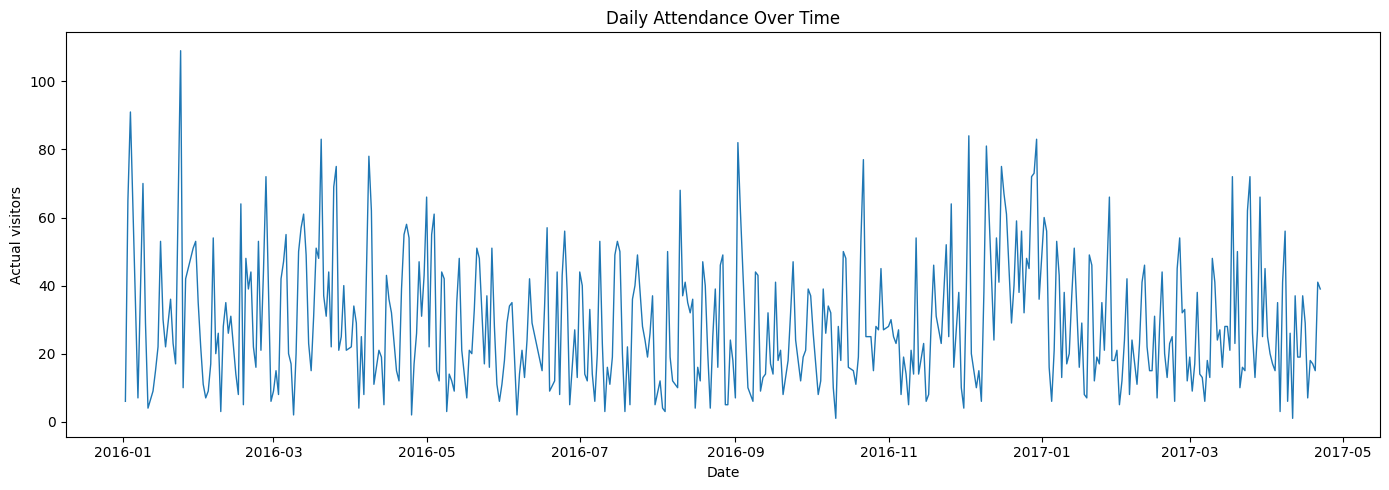

In [ ]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    x="date",
    y="visitors",
    data=df,
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Actual visitors")
plt.title("Daily Attendance Over Time")
plt.tight_layout()
plt.show()

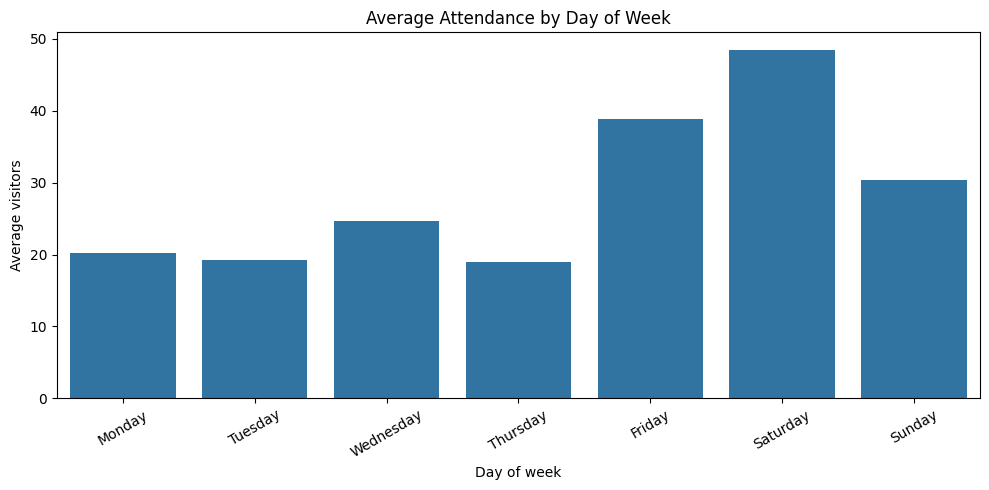

In [ ]:
plt.figure(figsize=(10, 5))

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

sns.barplot(
    x="day_of_week",
    y="visitors",
    data=df,
    estimator= "mean", # Seaborn will calculate the mean for each day
    errorbar = None, # Remove error bars
    order=weekday_order, # Ensure the days are in the correct order
)

plt.xlabel("Day of week")
plt.ylabel("Average visitors")
plt.title("Average Attendance by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

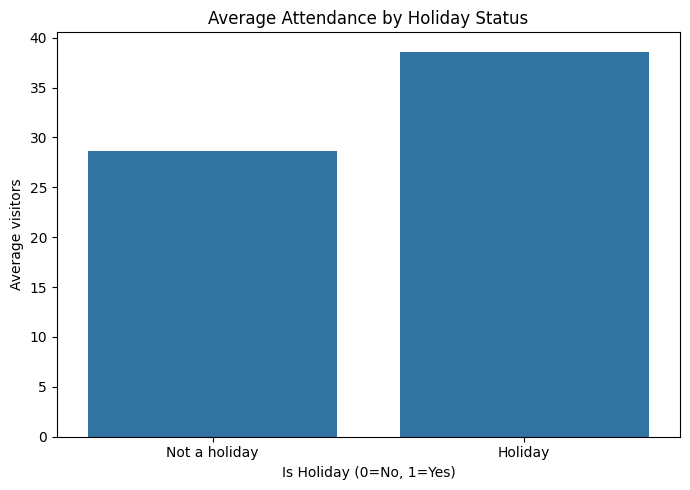

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x="is_holiday",
    y="visitors",
    data=df,
    estimator='mean', # Seaborn will calculate the mean for each holiday status
    errorbar = None, # Remove error bars
)

plt.xlabel("Is Holiday (0=No, 1=Yes)")
plt.ylabel("Average visitors")
plt.title("Average Attendance by Holiday Status")
plt.xticks([0, 1], ['Not a holiday', 'Holiday']) # Custom labels for clarity
plt.tight_layout()
plt.show()

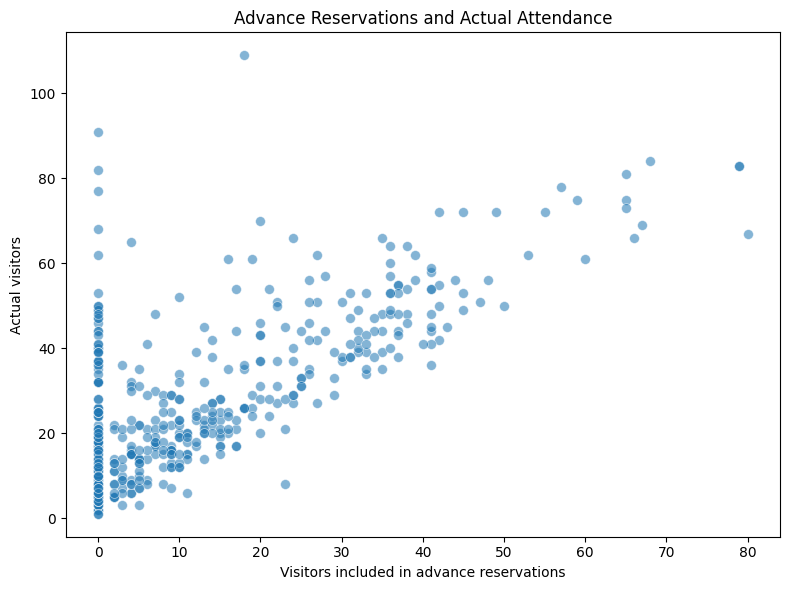

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="reserved_visitors",
    y="visitors",
    data=df,
    alpha=0.55, # Adjust transparency for overlapping points
    s=50,       # Adjust point size
)

plt.xlabel("Visitors included in advance reservations")
plt.ylabel("Actual visitors")
plt.title("Advance Reservations and Actual Attendance")
plt.tight_layout()
plt.show()

# Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

## Preparing the Dataset

In [ ]:
features_list = ['reserved_visitors','is_holiday','is_weekend','month']
X = df[features_list]
X

In [ ]:
features_list = ['reserved_visitors']
target = 'visitors'

In [ ]:
X = df[features_list]
X

,reserved_visitors
0,0
1,4
2,0
3,5
4,20
...,...
432,12
433,17
434,15
435,40


In [ ]:
y = df[target]
y

,visitors
0,6
1,65
2,91
3,7
4,70
...,...
432,18
433,17
434,15
435,41


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Total training data points: {len(X_train)}")
print(f"Total testing data points: {len(X_test)}")

Total training data points: 349
Total testing data points: 88


In [ ]:
def prepare_dataset(df, feature_list,target):
  X = df[feature_list].copy()
  y = df[target].copy()
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  return X_train, X_test, y_train, y_test

In [ ]:
features_list = ['reserved_visitors']
target = 'visitors'
X_train, X_test, y_train, y_test = prepare_dataset(df, features_list, target)
print(f"Total training data points: {len(X_train)}")
print(f"Total testing data points: {len(X_test)}")

Total training data points: 349
Total testing data points: 88


## Fitting the Model to the Training Data

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
def train_model(X_train, y_train):
  model = LinearRegression()
  model.fit(X_train, y_train)
  return model

In [ ]:
model = train_model(X_train, y_train)

In [ ]:
print(f"Model Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")

Model Coefficient (slope): 0.80
Model Intercept: 18.66


## Evaluating the Fitted Model using Test Data

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# Create a DataFrame with actual and predicted values
results_df = pd.DataFrame({
    'Actual': y_test.round(2),
    'Predicted': y_pred.round(2)
})

# Display the top 10 rows
results_df['Error'] = (results_df['Actual'] - results_df['Predicted']).abs().round(2)
results_df.head(10)

,Actual,Predicted,Error
395,24,31.39,7.39
78,40,37.75,2.25
278,27,37.75,10.75
305,15,25.82,10.82
325,73,70.36,2.64
289,8,21.85,13.85
218,24,18.66,5.34
82,29,23.44,5.56
432,18,28.21,10.21
402,23,21.85,1.15


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mae

7.7071758904199275

R² tells us how much of the variance in the actual values the model is able to explain.

R² = 1 → Perfect model

R² = 0 → Model predicts no better than the average

R² < 0 → Model is worse than guessing

In [ ]:
r2 = r2_score(y_test, y_pred)
r2

0.7226609755525473

In [ ]:
def evaluate_model(model, X_test, y_test):
  y_pred = model.predict(X_test)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  print(f"Mean Absolute Error on Test Set: {mae:.2f}")
  print(f"R-squared on Test Set: {r2:.2f}")
  return y_pred

In [ ]:
y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 7.71
R-squared on Test Set: 0.72


## Plotting the Fitted Line

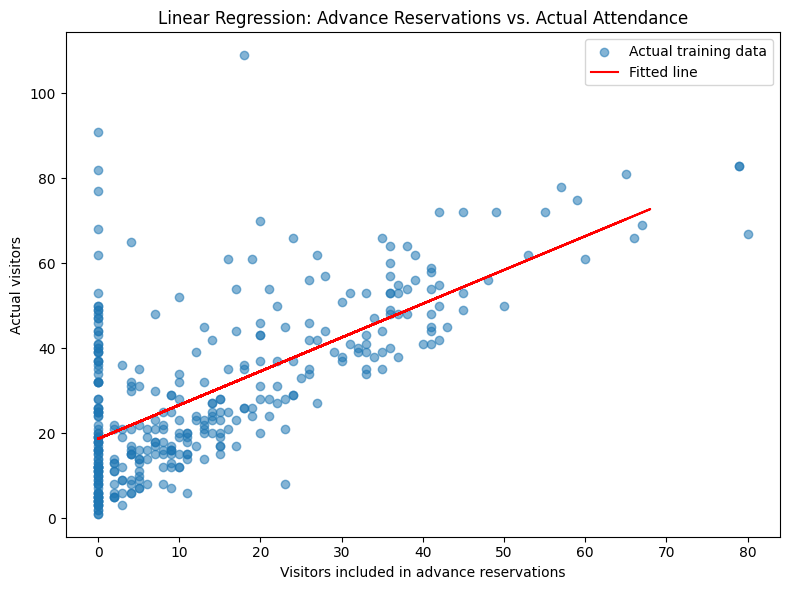

In [ ]:
# Plot the fitted line
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, alpha=0.55, label='Actual training data')
plt.plot(X_test, y_pred, color='red', label='Fitted line')

plt.xlabel("Visitors included in advance reservations")
plt.ylabel("Actual visitors")
plt.title("Linear Regression: Advance Reservations vs. Actual Attendance")
plt.legend()
plt.tight_layout()
plt.show()

# Fitting a Model with Multiple Input Features

In [ ]:
features_list = ['reserved_visitors']
target = 'visitors'

X_train, X_test, y_train, y_test = prepare_dataset(df, features_list, target)

model = train_model(X_train,y_train)

y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 7.71
R-squared on Test Set: 0.72


In [ ]:
features_list = ['reserved_visitors','is_holiday']
target = 'visitors'

X_train, X_test, y_train, y_test = prepare_dataset(df, features_list, target)

model = train_model(X_train,y_train)

y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 7.57
R-squared on Test Set: 0.73


In [ ]:
features_list = ['reserved_visitors','is_holiday','is_weekend','month']
target = 'visitors'

X_train, X_test, y_train, y_test = prepare_dataset(df, features_list, target)

model = train_model(X_train,y_train)

y_pred = evaluate_model(model, X_test, y_test)

Mean Absolute Error on Test Set: 6.90
R-squared on Test Set: 0.74


# What if you want to predict the number of visitors for a new day?

In [ ]:
new_day = pd.DataFrame(
              {
                  "reserved_visitors": [25],
                  "is_holiday": [0],
                  "is_weekend": [0],
                  "month": [4]
              }
          )
new_day

,reserved_visitors,is_holiday,is_weekend,month
0,25,0,0,4


In [ ]:
predicted_visitors = model.predict(new_day)
predicted_visitors

array([33.32798387])

In [ ]:
new_day = pd.DataFrame(
              {
                  "reserved_visitors": [25],
                  "is_holiday": [1],
                  "is_weekend": [1],
                  "month": [12]
              }
          )
new_day

,reserved_visitors,is_holiday,is_weekend,month
0,25,1,1,12


In [ ]:
predicted_visitors = model.predict(new_day)
predicted_visitors

array([55.24420693])